# Malawi Elections (1994-2020): A Behavioural-Metrics Analysis

**Goal.** Turn a cleaned polling-results dataset into a set of *quantitative political-behaviour metrics*

This notebook is written to be **read top-to-bottom**. Every metric is preceded by a short explanation of *what it measures, the formula, and why it's the right tool for the question*.

### The seven metrics

| # | Metric | Political question it answers |
|---|--------|------------------------------|
| 1 | Effective Number of competitors (Laakso-Taagepera) | How fragmented is the vote? Did 2020 *consolidate* it? |
| 2 | Margin of victory + competitiveness tier | Which seats are safe vs genuine "swing markets"? |
| 3 | Pedersen volatility | How much does party support churn between elections? |
| 4 | Regional concentration (nationalisation proxy) | Is a party regional or national? Is Malawi de-regionalising? |
| 5 | Split-ticket divergence | Do voters back one party for President and another for MP? |
| 6 | Wasted-vote share | How much of the vote elects nobody under plurality? |
| 7 | Incumbent re-election rate | Do sitting MPs survive? *(and a lesson in join fragility)* |


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

DATA = "/Volumes/workspace/mec/mec/malawi_elections_enriched.parquet"


## 1. Load & basic hygiene

read the CSV, strip stray whitespace on the columns we join on, and build one **stable district key** (upper-cased) so `Lilongwe` and `LILONGWE` never split into two districts.

In [0]:
def load(path=DATA):
    df = pd.read_parquet(path)
    for c in ["region", "district", "constituency", "candidate", "party_canonical"]:
        df[c] = df[c].astype("string").str.strip()
    df["district_key"] = df["district"].str.upper()
    return df

df = load()
print(df.shape)
df.groupby(["year", "election_type"]).size()


(189419, 20)


year  election_type
1994  parliamentary      599
      presidential        96
1999  parliamentary      664
      presidential       130
2004  parliamentary     1195
2009  parliamentary     1161
      presidential       196
2014  parliamentary     1287
      presidential       336
2019  parliamentary    78473
      presidential     77406
2020  presidential     27876
dtype: int64

## 2. Separate the *votes* from the *denominators*

This is the heart of the cleaning. We split the raw table into two clean tables:

* **denoms** - exactly one row per lowest-grain unit (station for 2019/2020, constituency/district otherwise), carrying the vote totals. We use `.first()` because the value is identical on every candidate row of the unit.
* **votes** - candidate-level vote counts, which *are* one-per-candidate and so are summed normally.

In [0]:
def build_denoms(df):
    station = df[df.granularity.eq("station")]
    other   = df[~df.granularity.eq("station")]
    keys_stn = ["year","election_type","region","district","district_key",
                "constituency","centre","station"]
    keys_oth = ["year","election_type","region","district","district_key","constituency"]
    agg = dict(valid=("valid_votes","first"), null=("null_void","first"),
               total=("total_voted","first"), reg=("registered","first"))
    stn = station.groupby(keys_stn, dropna=False).agg(**agg).reset_index()
    oth = other.groupby(keys_oth, dropna=False).agg(**agg).reset_index()
    return stn, oth

stn, oth = build_denoms(df)
print("station-grain units:", len(stn), "| aggregated-grain units:", len(oth))
stn.head(3)


station-grain units: 31363 | aggregated-grain units: 1043


,year,election_type,region,district,district_key,constituency,centre,station,valid,null,total,reg
0,2019,parliamentary,Central,Dedza,DEDZA,Dedza Central,Chigwenembe School 14034,Station 1,397,7,404,NaN
1,2019,parliamentary,Central,Dedza,DEDZA,Dedza Central,Chigwenembe School 14034,Station 2,397,5,402,NaN
2,2019,parliamentary,Central,Dedza,DEDZA,Dedza Central,Chilamba School 14031,Station 1,384,3,387,NaN


## 3. Roll-ups

Two reusable roll-ups cover every metric below.

**To constituency** (finest grain we can share for parliamentary + 2019/2020 presidential) - used for fragmentation and seat margins.

**To district by party** (the *coarsest common grain*, the only one all elections share) - used for volatility, nationalisation and split-ticket.

Notice the denominator roll-up sums the **deduplicated** unit rows (`stn`, `oth`), never the raw candidate rows.

In [0]:
def votes_to_constituency(df):
    return (df.groupby(["year","election_type","region","district","district_key",
                        "constituency","candidate","party_canonical"], dropna=False)
              ["votes"].sum().reset_index())

def denoms_to_constituency(stn, oth):
    stn_c = (stn.groupby(["year","election_type","region","district","district_key",
                          "constituency"], dropna=False)
                [["valid","null","total","reg"]].sum(min_count=1).reset_index())
    return pd.concat([stn_c, oth[stn_c.columns]], ignore_index=True)

def votes_to_district_by_party(df):
    return (df.groupby(["year","election_type","region","district_key",
                        "party_canonical"], dropna=False)["votes"].sum().reset_index())

def denoms_to_district(stn, oth):
    a = stn.groupby(["year","election_type","district_key"], dropna=False)[["valid","null","total","reg"]].sum(min_count=1)
    b = oth.groupby(["year","election_type","district_key"], dropna=False)[["valid","null","total","reg"]].sum(min_count=1)
    return pd.concat([a, b]).reset_index()

const_votes  = votes_to_constituency(df)
const_denoms = denoms_to_constituency(stn, oth)
dist_votes   = votes_to_district_by_party(df)
dist_denoms  = denoms_to_district(stn, oth)
print("constituency-level candidate rows:", len(const_votes))
const_votes.head(3)


constituency-level candidate rows: 8919


,year,election_type,region,district,district_key,constituency,candidate,party_canonical,votes
0,1994,parliamentary,Central,Dedza,DEDZA,Dedza Central,D.C. Matope,AFORD,634
1,1994,parliamentary,Central,Dedza,DEDZA,Dedza Central,M.E.K. Chisale,MCP,17753
2,1994,parliamentary,Central,Dedza,DEDZA,Dedza Central,Rev. E. Chinkwita Phiri,UDF,2778


> **A note on independents.** There are ~43k rows with `party_canonical == "IND"`. Lumping every independent into one "party" would fake a huge bloc and distort fragmentation. So fragmentation and seat-margin metrics operate over **candidates** within a constituency (each candidate is a competitor); only the *cross-election party-trend* metrics aggregate by party, where treating independents as a residual bloc is the conventional choice.

---
## Metric 1 - Effective Number of competitors (Laakso-Taagepera)

$$\text{ENP} = \frac{1}{\sum_i s_i^{2}}\qquad s_i = \text{vote share of competitor } i$$

It's the "how many *real* players" number. Two equal parties → 2.0. One dominant party with fringe rivals → close to 1.0. It's the rigorous quantity behind the word *consolidation*: **if the 2020 Tonse Alliance really did fuse a fragmented field, presidential ENP must fall sharply from 2019 to 2020.**

In [0]:
def enp(votes):
    v = np.asarray(votes, dtype=float); v = v[v > 0]
    tot = v.sum()
    if tot <= 0: return np.nan
    s = v / tot
    return 1.0 / np.sum(s**2)

# parliamentary: fragmentation per seat, summarised by year
parl_enp = (const_votes[const_votes.election_type.eq("parliamentary")]
            .groupby(["year","district","constituency"])["votes"].apply(enp)
            .reset_index(name="enp"))
parl_enp_by_year = parl_enp.groupby("year")["enp"].median()

# presidential: ENP of the national candidate field
pres = const_votes[const_votes.election_type.eq("presidential")]
pres_nat = pres.groupby(["year","candidate"])["votes"].sum().reset_index()
pres_enp_by_year = pres_nat.groupby("year")["votes"].apply(enp)

print("Parliamentary median ENP by year:\n", parl_enp_by_year.round(2).to_string())
print("\nPresidential national ENP by year:\n", pres_enp_by_year.round(2).to_string())


Parliamentary median ENP by year:
 year
1994    1.57
1999    1.86
2004    2.91
2009    3.00
2014    3.44
2019    3.18

Presidential national ENP by year:
 year
1994    2.70
1999    2.09
2009    1.90
2014    3.70
2019    3.15
2020    1.95


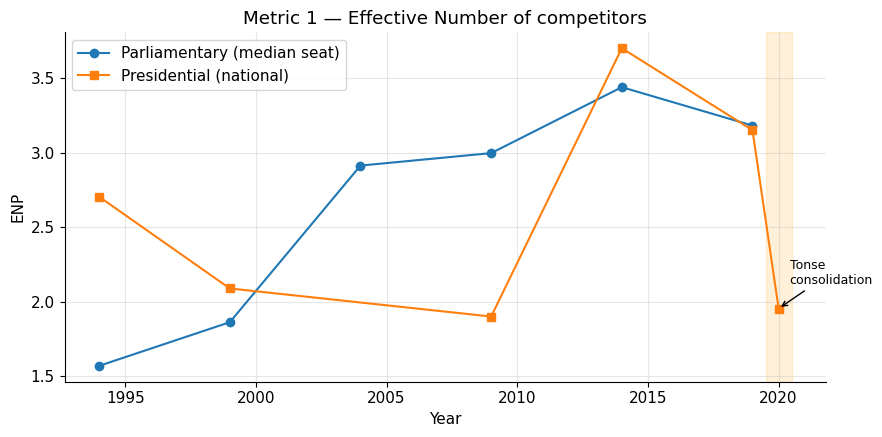

In [0]:
fig, ax = plt.subplots()
ax.plot(parl_enp_by_year.index, parl_enp_by_year.values, "o-", label="Parliamentary (median seat)")
ax.plot(pres_enp_by_year.index, pres_enp_by_year.values, "s-", label="Presidential (national)")
ax.axvspan(2019.5, 2020.5, color="orange", alpha=.15)
ax.annotate("Tonse\nconsolidation", (2020, pres_enp_by_year.loc[2020]),
            textcoords="offset points", xytext=(8, 18), fontsize=9,
            arrowprops=dict(arrowstyle="->"))
ax.set(title="Metric 1 - Effective Number of competitors", xlabel="Year", ylabel="ENP")
ax.legend(); plt.tight_layout(); plt.show()


**Reading it.** Parliamentary fragmentation climbs from ~1.6 (1994, near two-party) to ~3.4 by 2014 - Malawi becoming steadily more multiparty. The presidential line is the story your report is built on: it peaks in 2014, sits at ~3.15 in the annulled 2019 vote, then **collapses to ~1.95 in the 2020 re-run**. Same electorate, same candidates on offer - but the opposition stopped splitting. That single drop *is* the coalition effect, quantified.

## Metric 2 - Margin of victory & competitiveness tiers

For each seat, sort competitors by share and take **winner − runner-up**. Then bin into tiers:

* **tossup** < 10 pts &nbsp;•&nbsp; **lean** 10-20 pts &nbsp;•&nbsp; **safe** ≥ 20 pts

In [0]:
def margins(const_votes, etype):
    d = const_votes[const_votes.election_type.eq(etype)]
    def _one(g):
        g = g.sort_values("votes", ascending=False)
        tot = g["votes"].sum()
        if tot <= 0:
            return pd.Series({"winner_party": None, "margin": np.nan, "n_cand": len(g)})
        s = g["votes"].to_numpy() / tot
        return pd.Series({"winner_party": g["party_canonical"].iat[0],
                          "margin": s[0] - (s[1] if len(s) > 1 else 0.0),
                          "n_cand": len(g)})
    out = (d.groupby(["year","region","district","constituency"])
             .apply(_one, include_groups=False).reset_index())
    bins = pd.cut(out["margin"], [-0.01, .10, .20, 1.01], labels=["tossup","lean","safe"])
    out["tier"] = bins
    return out

parl_margins = margins(const_votes, "parliamentary")
tier_share = (parl_margins.groupby("year")["tier"].value_counts(normalize=True)
              .mul(100).unstack()[["safe","lean","tossup"]])
tier_share.round(1)


tier,safe,lean,tossup
year,,,
1994,88.1,5.6,6.2
1999,77.1,12.0,10.9
2004,51.6,24.5,23.9
2009,44.8,23.4,31.8
2014,39.1,27.1,33.9
2019,37.5,27.6,34.9


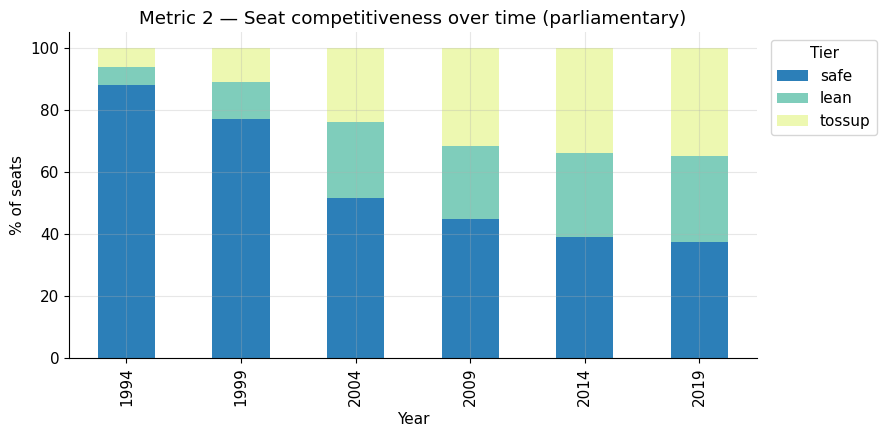

Presidential mean district margin 2019 vs 2020:
year
2019    0.466
2020    0.692


In [0]:
ax = tier_share.plot(kind="bar", stacked=True, color=["#2c7fb8","#7fcdbb","#edf8b1"])
ax.set(title="Metric 2 - Seat competitiveness over time (parliamentary)",
       ylabel="% of seats", xlabel="Year")
ax.legend(title="Tier", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

pres_margins = margins(const_votes, "presidential")
print("Presidential mean district margin 2019 vs 2020:")
print(pres_margins[pres_margins.year.isin([2019,2020])]
      .groupby("year")["margin"].mean().round(3).to_string())


Safe seats fall from **88%** (1994) to **~38%** (2019) while tossups rise from **6% to 35%** - the map is getting genuinely competitive. And presidentially, the mean district margin *widens* from 0.47 (2019) to 0.69 (2020): consolidation didn't just change the national winner, it turned close local three-ways into decisive two-way wins.

## Metric 2 (extended) - Presidential swing map, 2019 → 2020

Metric 1 told us the vote *consolidated*; a **swing map** shows **where** that consolidation actually landed. For each district we take MCP (Chakwera) presidential vote share in both elections and subtract:

$$\text{swing}_d = (\text{MCP share}_{d,\,2020}) - (\text{MCP share}_{d,\,2019})$$


In [0]:
import json
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.colors as mcolors

GEO = "/Volumes/workspace/mec/mec/malawi_districts.geojson"   # <-- ships alongside this notebook

def norm(s):
    s = str(s).lower().replace(" ", "")
    return {"chikhwawa": "chikwawa"}.get(s, s)   # spelling bridge to the boundary file

# district-level presidential shares for MCP & DPP, 2019 vs 2020
p = df[(df.election_type.eq("presidential")) & (df.year.isin([2019, 2020]))]
stn = p.groupby(["year","district","centre","station"])["valid_votes"].first().reset_index()
valid = stn.groupby(["year","district"])["valid_votes"].sum().rename("valid").reset_index()
votes = p.groupby(["year","district","party_canonical"])["votes"].sum().reset_index()
sh = votes.merge(valid, on=["year","district"])
sh["share"] = sh["votes"] / sh["valid"]

swing = (sh[sh.party_canonical.isin(["MCP","DPP"])]
         .pivot_table(index="district", columns=["party_canonical","year"], values="share"))
swing.columns = [f"{a}_{b}" for a, b in swing.columns]
swing["MCP_swing"] = swing["MCP_2020"] - swing["MCP_2019"]
swing["DPP_swing"] = swing["DPP_2020"] - swing["DPP_2019"]
swing = swing.reset_index()
swing["key"] = swing["district"].map(norm)
swing["region"] = (df.drop_duplicates("district").set_index("district")["region"]
                   .reindex(swing["district"]).values)
swing.sort_values("MCP_swing", ascending=False).round(3).head(6)


,district,DPP_2019,DPP_2020,MCP_2019,MCP_2020,MCP_swing,DPP_swing,key,region
21,Ntcheu,0.278,0.236,0.102,0.742,0.64,-0.042,ntcheu,Central
4,Chitipa,0.184,0.135,0.214,0.845,0.631,-0.05,chitipa,Northern
7,Karonga,0.265,0.15,0.226,0.836,0.61,-0.115,karonga,Northern
24,Rumphi,0.191,0.137,0.252,0.852,0.6,-0.054,rumphi,Northern
18,Nkhatabay,0.273,0.203,0.251,0.786,0.535,-0.07,nkhatabay,Northern
16,Mzimba,0.151,0.083,0.39,0.911,0.521,-0.067,mzimba,Northern


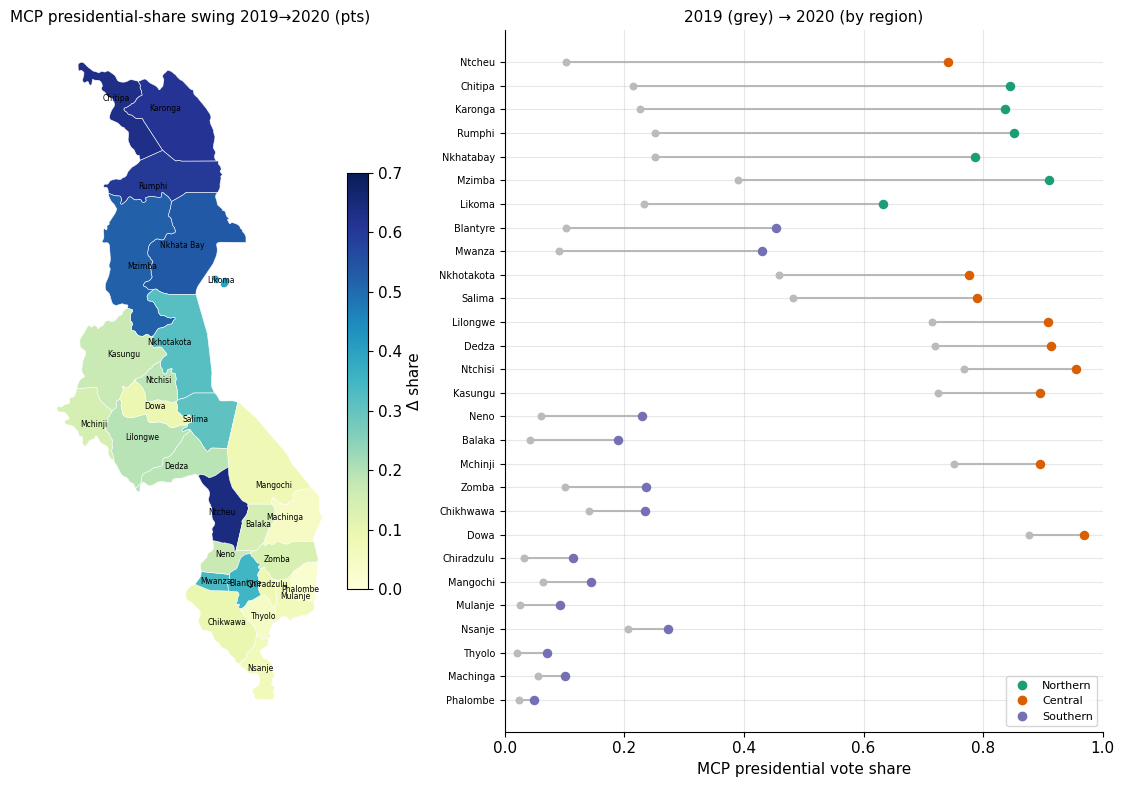

In [0]:
geo = json.load(open(GEO))
def polys_of(f):
    g = f["geometry"]
    return [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]
def centroid(polys):
    pts = np.vstack([np.array(r[0]) for r in polys])
    return pts[:, 0].mean(), pts[:, 1].mean()

val = dict(zip(swing["key"], swing["MCP_swing"]))
fig, (axm, axd) = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [1, 1.15]})

vmax = np.ceil(swing["MCP_swing"].max() * 10) / 10
cmap, nrm = plt.cm.YlGnBu, mcolors.Normalize(0, vmax)
for f in geo["features"]:
    k, ps = f["properties"]["key"], polys_of(f)
    c = cmap(nrm(val.get(k, np.nan))) if k in val else "#dddddd"
    for ring in ps:
        axm.add_patch(MplPolygon(ring[0], closed=True, facecolor=c, edgecolor="white", linewidth=.4))
    cx, cy = centroid(ps)
    axm.text(cx, cy, f["properties"]["district"], fontsize=5.5, ha="center", va="center")
axm.autoscale(); axm.set_aspect("equal"); axm.axis("off")
axm.set_title("MCP presidential-share swing 2019→2020 (pts)", fontsize=11)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=nrm); sm.set_array([])
fig.colorbar(sm, ax=axm, fraction=.04, pad=.02).set_label("Δ share")

reg_color = {"Northern": "#1b9e77", "Central": "#d95f02", "Southern": "#7570b3"}
dd = swing.sort_values("MCP_swing"); y = np.arange(len(dd))
for yi, (_, r) in zip(y, dd.iterrows()):
    axd.plot([r.MCP_2019, r.MCP_2020], [yi, yi], color="#bbb", lw=1.5, zorder=1)
    axd.scatter(r.MCP_2019, yi, color="#bbb", s=22, zorder=2)
    axd.scatter(r.MCP_2020, yi, color=reg_color.get(r.region, "#555"), s=34, zorder=3)
axd.set_yticks(y); axd.set_yticklabels(dd["district"], fontsize=7)
axd.set_xlim(0, 1); axd.set_xlabel("MCP presidential vote share")
axd.set_title("2019 (grey) → 2020 (by region)", fontsize=11)
from matplotlib.lines import Line2D
axd.legend(handles=[Line2D([0],[0], marker="o", ls="", color=c, label=r)
                    for r, c in reg_color.items()], fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

import os; os.makedirs("outputs", exist_ok=True)
swing.to_csv("outputs/m2b_presidential_swing.csv", index=False)


**Reading the swing map.** MCP gained ground in *every* district - but wildly unevenly. The dark cluster is the **North** (Chitipa +63pts, Karonga +61, Rumphi +60, Nkhata Bay +54, Mzimba +52) plus **Ntcheu +64** in the Centre. These are precisely Saulos Chilima's UTM strongholds from 2019: when UTM folded into the Tonse Alliance, that vote transferred almost wholesale to Chakwera. The Southern DPP heartland (Thyolo, Mulanje, Phalombe, Machinga) barely moved. So the 2020 result wasn't a national mood-swing - it was a **geographically targeted coalition transfer**, and the map makes that unmistakable in a way the national ENP number alone cannot.

## Metric 3 - Pedersen volatility

$$V = \tfrac{1}{2}\sum_p \lvert s_{p,t} - s_{p,t-1}\rvert \times 100$$

The net percentage of the vote that *switched parties* between two consecutive elections of the same type. Computed at **district** grain (the common denominator), then also nationally.

⚠️ **Caveat baked into the data:** there is no 2004 presidential file, so the presidential 1999→2009 "step" spans a decade and two party systems

In [0]:
def pedersen_national(dist_votes, etype):
    d = dist_votes[dist_votes.election_type.eq(etype)]
    nat = d.groupby(["year","party_canonical"])["votes"].sum().reset_index()
    nat["share"] = nat["votes"] / nat.groupby("year")["votes"].transform("sum")
    piv = nat.pivot_table(index="year", columns="party_canonical",
                          values="share", fill_value=0.0).sort_index()
    ys = list(piv.index)
    return pd.DataFrame([{"from": a, "to": b,
                          "volatility_pct": 0.5*np.abs(piv.loc[b]-piv.loc[a]).sum()*100}
                         for a, b in zip(ys, ys[1:])])

vol_parl = pedersen_national(dist_votes, "parliamentary")
vol_pres = pedersen_national(dist_votes, "presidential")
print("Parliamentary volatility:\n", vol_parl.round(1).to_string(index=False))
print("\nPresidential volatility:\n", vol_pres.round(1).to_string(index=False))


Parliamentary volatility:
  from   to  volatility_pct
 1994 1999             8.8
 1999 2004            38.9
 2004 2009            47.4
 2009 2014            24.9
 2014 2019            23.5

Presidential volatility:
  from   to  volatility_pct
 1994 1999            18.9
 1999 2009            68.8
 2009 2014            35.5
 2014 2019            30.9
 2019 2020            25.6


Parliamentary churn peaks at **~47%** around 2004-09 (the UDF→DPP realignment after Bingu wa Mutharika broke from his own party) and settles into the low-20s. Even the 2019→2020 presidential *re-run* posts **~26%** volatility - proof that "similar-looking" elections can hide massive reshuffling under the hood, exactly the UTM-into-MCP flow.

## Metric 4 - Regional concentration (nationalisation proxy)

For each party-year, split its votes across the three regions and compute a Herfindahl index:

$$H = \sum_{r \in \{N,C,S\}} (\text{region share})^2$$

$H = 1$ → every vote from one region (purely regional). $H \to 1/3 \approx 0.33$ → evenly national. It directly tests the "regional brand loyalty" thesis and shows whether coalitions broaden a party's map.

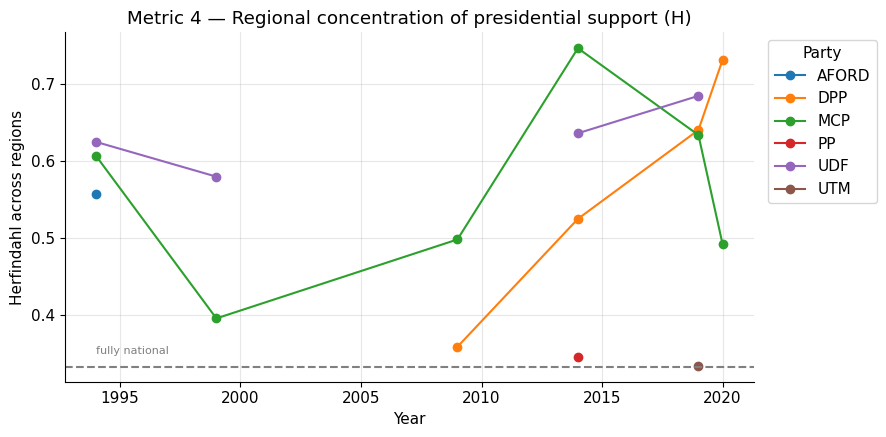

party_canonical,AFORD,DPP,MCP,PP,UDF,UTM
year,,,,,,
1994,0.56,<NA>,0.61,<NA>,0.62,<NA>
1999,<NA>,<NA>,0.4,<NA>,0.58,<NA>
2009,<NA>,0.36,0.5,<NA>,<NA>,<NA>
2014,<NA>,0.52,0.75,0.35,0.64,<NA>
2019,<NA>,0.64,0.63,<NA>,0.68,0.33
2020,<NA>,0.73,0.49,<NA>,<NA>,<NA>


In [0]:
def regional_concentration(df, etype, min_votes=20000):
    d = df[df.election_type.eq(etype)]
    reg = d.groupby(["year","party_canonical","region"])["votes"].sum().reset_index()
    reg["rshare"] = reg["votes"] / reg.groupby(["year","party_canonical"])["votes"].transform("sum")
    h = (reg.groupby(["year","party_canonical"])
            .agg(H=("rshare", lambda s: np.sum(s**2)),
                 total_votes=("votes","sum"), top_region=("rshare","max")).reset_index())
    return h[h.total_votes >= min_votes]

rc = regional_concentration(df, "presidential")
majors = ["MCP","UDF","DPP","AFORD","UTM","PP"]
pivotH = (rc[rc.party_canonical.isin(majors)]
          .pivot_table(index="year", columns="party_canonical", values="H"))
ax = pivotH.plot(marker="o")
ax.axhline(1/3, ls="--", color="grey"); ax.text(1994, .35, "fully national", color="grey", fontsize=8)
ax.set(title="Metric 4 - Regional concentration of presidential support (H)",
       ylabel="Herfindahl across regions", xlabel="Year")
ax.legend(title="Party", bbox_to_anchor=(1.01,1)); plt.tight_layout(); plt.show()
pivotH.round(2)


UTM in 2019 is the most *national* actor on the board (H≈0.33 - Chilima drew evenly everywhere), while MCP in 2014 is the most *regional* (H≈0.75, locked in the Centre). Watch MCP fall to ~0.49 in 2020: the Tonse coalition didn't just add votes, it **broadened MCP's geographic base**. DPP, by contrast, stays southern throughout.

## Metric 5 - Split-ticket divergence

Only possible in years with **both** a presidential and parliamentary race (1994, 1999, 2009, 2014, 2019). At district grain, for each party:

$$\text{divergence} = (\text{presidential vote share}) - (\text{parliamentary vote share})$$

Large **positive** → the party's presidential candidate ran *ahead* of its MPs (a coattail / personal-vote effect at the top of the ticket).

In [0]:
def split_ticket(dist_votes, dist_denoms):
    shared = [1994, 1999, 2009, 2014, 2019]
    d = dist_votes[dist_votes.year.isin(shared)].merge(
        dist_denoms[["year","election_type","district_key","valid"]],
        on=["year","election_type","district_key"], how="left")
    d["share"] = d["votes"] / d["valid"]
    piv = d.pivot_table(index=["year","district_key","party_canonical"],
                        columns="election_type", values="share").reset_index()
    piv = piv.dropna(subset=["presidential","parliamentary"])
    piv["divergence"] = piv["presidential"] - piv["parliamentary"]
    summary = (piv.groupby(["year","party_canonical"])
                 .agg(mean_div=("divergence","mean"), n_dist=("divergence","size"))
                 .reset_index())
    return piv, summary

_, st_sum = split_ticket(dist_votes, dist_denoms)
st_sum[st_sum.party_canonical.isin(["MCP","UDF","DPP","AFORD"])].round(3)


,year,party_canonical,mean_div,n_dist
0,1994,AFORD,0.001,22
1,1994,MCP,0.006,22
3,1994,UDF,0.018,22
5,1999,MCP,0.14,24
7,1999,UDF,0.054,24
9,2009,AFORD,-0.04,6
10,2009,DPP,0.307,27
12,2009,MCP,0.161,26
17,2014,DPP,0.177,24
19,2014,MCP,0.075,24


The standout is **DPP in 2009: +0.31** - Bingu wa Mutharika's presidential vote ran ~31 points ahead of DPP's parliamentary vote in the average district, because DPP was a young party with few local candidates but a wildly popular incumbent president. That's a textbook coattail signature, and your data shows it cleanly.

## Metric 6 - Wasted-vote share (the FPTP critique)

Under plurality, every vote not cast for the winner elects nobody. A simple, powerful proxy per seat:

$$\text{wasted} = 1 - (\text{winner's share of valid votes})$$

As fields fragment, winners win with smaller pluralities, so *more* of the electorate goes unrepresented - the structural argument behind Malawi's move to 50%+1 for the presidency.

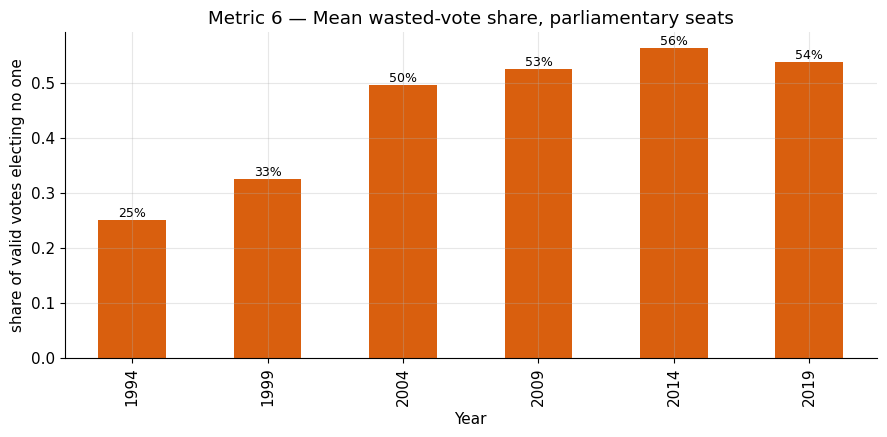

In [0]:
d = const_votes[const_votes.election_type.eq("parliamentary")]
parl_winners = (d.sort_values("votes", ascending=False)
             .groupby(["year","district","constituency"]).first().reset_index()
             .merge(const_denoms[const_denoms.election_type.eq("parliamentary")]
                    [["year","district","constituency","valid"]],
                    on=["year","district","constituency"], how="left"))
parl_winners["wasted_share"] = 1 - parl_winners["votes"] / parl_winners["valid"]
wasted_by_year = parl_winners.groupby("year")["wasted_share"].mean()

ax = wasted_by_year.plot(kind="bar", color="#d95f0e")
ax.set(title="Metric 6 - Mean wasted-vote share, parliamentary seats",
       ylabel="share of valid votes electing no one", xlabel="Year")
for i, v in enumerate(wasted_by_year): ax.text(i, v+.005, f"{v:.0%}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


From **25%** wasted (1994) to **56%** (2014): by the 2010s the average winning MP was opposed by more voters than backed them.

## Metric 7 - Incumbent re-election *(and a lesson in join fragility)*

We match each seat's winner at election *t* to candidates in the same constituency at *t+1* by **surname**, and check whether they re-ran and re-won.

This metric doubles as a **data-quality lesson**: it only works if constituency names *and* candidate-name formats are consistent across the two files.

In [0]:
def surname(name):
    if pd.isna(name): return None
    toks = [t for t in str(name).replace(".", " ").split() if t.isalpha()]
    return toks[-1].upper() if toks else None

d = const_votes[const_votes.election_type.eq("parliamentary")].copy()
d["surname"]  = d["candidate"].map(surname)
d["cons_key"] = d["district"].str.upper() + "|" + d["constituency"].str.upper()
winners = d.sort_values("votes", ascending=False).groupby(["year","cons_key"]).first().reset_index()

years, rows = sorted(winners.year.unique()), []
for a, b in zip(years, years[1:]):
    wa = winners[winners.year.eq(a)]
    ran = d[d.year.eq(b)].groupby("cons_key")["surname"].apply(set)
    won = winners[winners.year.eq(b)].set_index("cons_key")["surname"].to_dict()
    n = rr = rw = 0
    for _, r in wa.iterrows():
        ck, sn = r["cons_key"], r["surname"]
        if ck not in ran.index or sn is None: continue
        n += 1
        if sn in ran.loc[ck]:
            rr += 1
            if won.get(ck) == sn: rw += 1
    rows.append({"from": a, "to": b, "seats_matched": n,
                 "rerun_rate": rr/n if n else np.nan, "rewin_rate": rw/n if n else np.nan})
pd.DataFrame(rows).round(3)


,from,to,seats_matched,rerun_rate,rewin_rate
0,1994,1999,139,0.453,0.295
1,1999,2004,120,0.592,0.300
2,2004,2009,122,0.025,0.000
3,2009,2014,191,0.031,0.010
4,2014,2019,167,0.802,0.269


**Read this table skeptically.** The 2004→2009 and 2009→2014 rerun rates crater to 2-3% - which would mean almost no MP ever stood twice. That's false; it's a **join artifact**: those file pairs format constituency or candidate names differently, so the surname/constituency key fails to match. The 1994→1999, 1999→2004 and 2014→2019 pairs (45-80%) are believable.

**The lesson:** a metric is only as trustworthy as the join beneath it.

---
# Part B - Descriptive analysis: *who won where, and by how much*

Metrics 1-7 were *behavioural* - they compress the electorate's behaviour into single defensible numbers (fragmentation, volatility, and so on). A findings report and a dashboard also need the plain **descriptive** layer underneath them: who won each district, how many seats each party took, how the vote split by region, how lopsided the wins were. This section builds those views as reusable functions + charts.


In [0]:
# --- B0: canonical district + reusable descriptive roll-ups -------------------
# Malawi's 28 districts, mapping every raw spelling (and the Mzuzu city) onto one label.
_DIST = {
    "CHIKHWAWA":"Chikwawa", "CHIKWAWA":"Chikwawa",
    "NKHATA BAY":"Nkhata Bay", "NKHATABAY":"Nkhata Bay",
    "NKHOTA KOTA":"Nkhotakota", "NKHOTAKOTA":"Nkhotakota",
    "M'MBELWA (MZIMBA)":"Mzimba", "MZIMBA":"Mzimba", "MZUZU":"Mzimba",
}
def canon_district(series):
    u = series.astype("string").str.upper().str.strip()
    return u.map(lambda x: _DIST.get(x, x.title() if isinstance(x, str) else x)).astype("string")

df["district_c"] = canon_district(df["district"])   # canonical name
df["dk"]         = df["district_c"].str.upper()      # canonical key for joins
# one region per district (majority vote in case of stray mislabels)
region_of = (df.dropna(subset=["region"]).groupby("dk")["region"]
               .agg(lambda s: s.value_counts().index[0]))

print("raw district spellings:", df["district"].nunique(),
      "-> canonical districts:", df["district_c"].nunique())

# Party brand-ish colours so every chart in Part B is legible & consistent
PARTY_COLORS = {"MCP":"#1f6f3d","DPP":"#0033a0","UDF":"#e8b100","UTM":"#7b2d8b",
                "PP":"#e07b00","AFORD":"#c0392b","IND":"#7f8c8d","MMD":"#16a085",
                "PETRA":"#8e6e53","NARC":"#95a5a6","MAFUNDE":"#34495e"}
pcol = lambda p: PARTY_COLORS.get(p, "#bbbbbb")

# candidate votes rolled to canonical district (reused all through Part B)
def votes_by_district(df):
    v = (df.groupby(["year","election_type","dk","candidate","party_canonical"],
                    dropna=False)["votes"].sum().reset_index())
    v["region"] = v["dk"].map(region_of)
    v["district"] = v["dk"].str.title()
    return v
dvc = votes_by_district(df)
dvc.head(3)


raw district spellings: 33 -> canonical districts: 28


,year,election_type,dk,candidate,party_canonical,votes,region,district
0,1994,parliamentary,BLANTYRE,A. Ndaila Onani,AFORD,4275,Southern,Blantyre
1,1994,parliamentary,BLANTYRE,A.E.F. Ngalande,MCP,3017,Southern,Blantyre
2,1994,parliamentary,BLANTYRE,A.K. Somba,AFORD,185,Southern,Blantyre


## B1 - National vote share by party, by year

The most-requested chart in any elections report: **what slice of the national vote each party won, election by election.** We sum candidate votes to the party-year level and divide by that year's total. Two views of the same table - a **stacked area** (good for reading a party's *trajectory*) and a **stacked bar** (good for reading a single year's *split*).

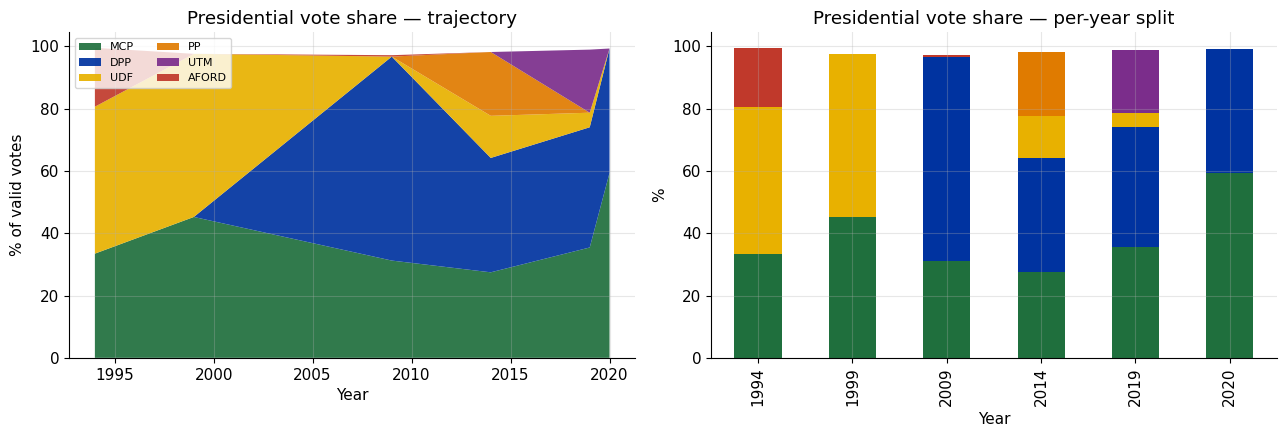

party_canonical,MCP,DPP,UDF,PP,UTM,AFORD
year,,,,,,
1994,33.4,0.0,47.1,0.0,0.0,18.9
1999,45.2,0.0,52.3,0.0,0.0,0.0
2009,31.2,65.4,0.0,0.0,0.0,0.5
2014,27.4,36.7,13.5,20.5,0.0,0.0
2019,35.4,38.6,4.7,0.0,20.2,0.0
2020,59.3,39.9,0.0,0.0,0.0,0.0


In [0]:
# --- B1: national vote share -------------------------------------------------
def party_year_share(df, etype, level=None):
    """Party vote share by year (level=None) or by year x region (level='region')."""
    d = df[df.election_type.eq(etype)].copy()
    if level == "region":
        d["grp"] = d["dk"].map(region_of)
    keys  = ["year","party_canonical"] + (["grp"] if level=="region" else [])
    dkeys = ["year"] + (["grp"] if level=="region" else [])
    g = d.groupby(keys)["votes"].sum().reset_index()
    den = d.groupby(dkeys)["votes"].sum().rename("den").reset_index()
    g = g.merge(den, on=dkeys)
    g["share"] = g["votes"] / g["den"] * 100
    return g

pres = party_year_share(df, "presidential")
piv  = pres.pivot_table(index="year", columns="party_canonical", values="share", fill_value=0)
keep = piv.sum().sort_values(ascending=False).head(6).index.tolist()   # 6 biggest cumulatively
piv  = piv[keep]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.stackplot(piv.index, [piv[p] for p in keep], labels=keep,
             colors=[pcol(p) for p in keep], alpha=.92)
a1.set(title="Presidential vote share - trajectory", xlabel="Year", ylabel="% of valid votes")
a1.legend(loc="upper left", fontsize=8, ncol=2)
piv.plot(kind="bar", stacked=True, ax=a2, color=[pcol(p) for p in keep], legend=False)
a2.set(title="Presidential vote share - per-year split", xlabel="Year", ylabel="%")
plt.tight_layout(); plt.show()

piv.round(1)


The numbers line up with the historical record: UDF's founding wins (47% in 1994, 52% in 1999), Bingu's 2009 DPP landslide (65%), the fragmented 2014 field, and the **2019 → 2020 flip** - MCP jumping from 35% to **59%** as the Tonse Alliance consolidated the opposition vote. That single column is Metric 1's ENP collapse, shown as raw share.

## B2 - District winner map (who carried each district)

A **choropleth coloured by winning party** is the single most legible artefact for a report cover or dashboard landing page. We reuse the same open **Natural Earth admin-2** GeoJSON and matplotlib-patch drawing as the swing map (no geopandas needed), and the same `key` convention. Because `district_c` is already canonical, `norm()` lines it up with the boundary file's keys directly.

Below: presidential **2019 vs 2020** side by side. The colour is the winning party; the label is that party's **win %** in the district.

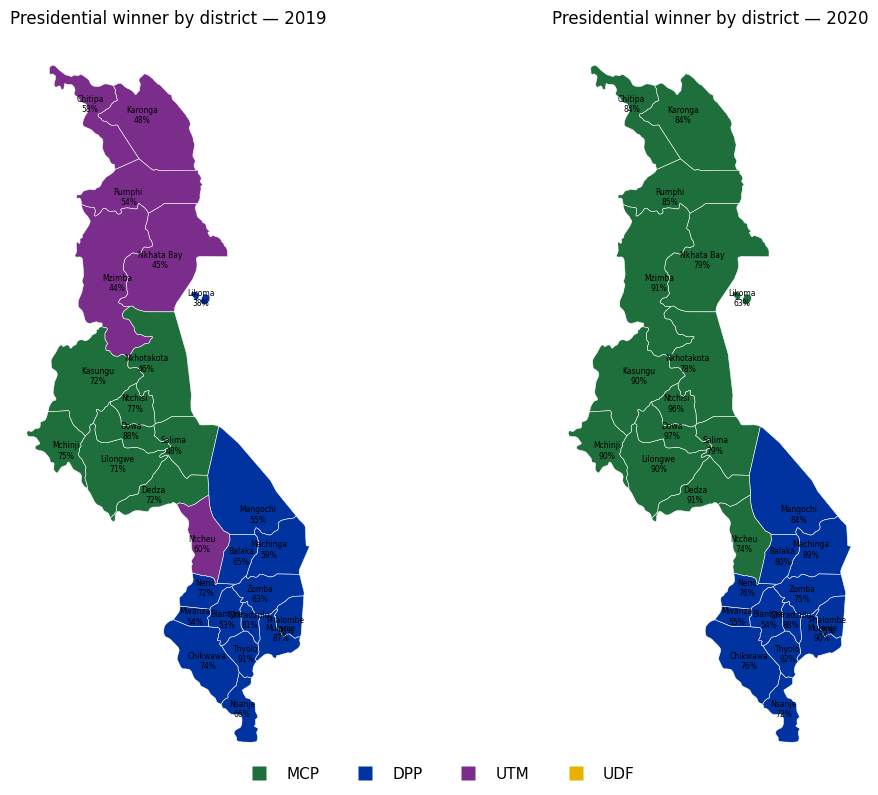

In [0]:
# --- B2: winner-by-district choropleth (presidential 2019 vs 2020) -----------
import json
from matplotlib.patches import Polygon as MplPolygon

GEO = "/Volumes/workspace/mec/mec/malawi_districts.geojson"   # ships beside this notebook
def norm(s):
    s = str(s).lower().replace(" ", "")
    return {"chikhwawa":"chikwawa"}.get(s, s)

def district_winners(dvc, etype):
    d = dvc[dvc.election_type.eq(etype)].sort_values("votes", ascending=False)
    win = d.groupby(["year","region","dk","district"], as_index=False).first()
    tot = d.groupby(["year","dk"])["votes"].sum().rename("dist_total").reset_index()
    run = (d.groupby(["year","dk"]).nth(1).reset_index()[["year","dk","votes"]]
             .rename(columns={"votes":"runner_votes"}))
    win = win.merge(tot, on=["year","dk"]).merge(run, on=["year","dk"], how="left")
    win["win_pct"]    = win["votes"] / win["dist_total"] * 100
    win["margin_pct"] = (win["votes"] - win["runner_votes"].fillna(0)) / win["dist_total"] * 100
    win["key"] = win["district"].map(norm)
    return win

pw = district_winners(dvc, "presidential")
geo = json.load(open(GEO))
polys_of = lambda f: ([f["geometry"]["coordinates"]] if f["geometry"]["type"]=="Polygon"
                      else f["geometry"]["coordinates"])

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
for ax, yr in zip(axes, [2019, 2020]):
    wy = pw[pw.year.eq(yr)].set_index("key")
    for f in geo["features"]:
        k = f["properties"]["key"]
        party = wy["party_canonical"].get(k)
        color = pcol(party) if party else "#eeeeee"
        for ring in polys_of(f):
            ax.add_patch(MplPolygon(ring[0], closed=True, facecolor=color,
                                    edgecolor="white", linewidth=.4))
        if k in wy.index:
            xs = np.vstack([np.array(r[0]) for r in polys_of(f)])
            ax.text(xs[:,0].mean(), xs[:,1].mean(),
                    f"{f['properties']['district']}\n{wy['win_pct'].get(k,0):.0f}%",
                    fontsize=5.5, ha="center", va="center")
    ax.autoscale(); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"Presidential winner by district - {yr}", fontsize=12)

present = [p for p in ["MCP","DPP","UTM","UDF"] if p in pw.party_canonical.values]
handles = [plt.Line2D([0],[0], marker="s", ls="", markerfacecolor=pcol(p),
                      markeredgecolor="none", markersize=10, label=p) for p in present]
fig.legend(handles=handles, loc="lower center", ncol=len(present), frameon=False)
plt.tight_layout(); plt.show()


The two maps *are* the coalition story in one glance: in **2019** the North is UTM (purple), the Centre mostly MCP (green) with a DPP/UTM speckle, and the South solid DPP (blue). In **2020** the North and Centre fuse into one MCP bloc while the DPP is compressed into its 13 Southern districts - the exact geography Metric 4 (nationalisation) and the swing map quantified.

## B3 - Counts, not just shares: districts won by region, and parliamentary seats

Shares answer *how much*; a report also needs *how many*. Two count views:

1. **Presidential districts won, by region and party** - the cleanest table for "who controls which region".
2. **Parliamentary seats won by party, by year** - the seat-count history of the National Assembly (independents included, since they are a huge bloc in Malawi).


Presidential districts won — 2019
party_canonical  DPP  MCP  UTM
region                        
Central            0    8    1
Northern           1    0    5
Southern          13    0    0

Presidential districts won — 2020
party_canonical  DPP  MCP
region                   
Central            0    9
Northern           0    6
Southern          13    0


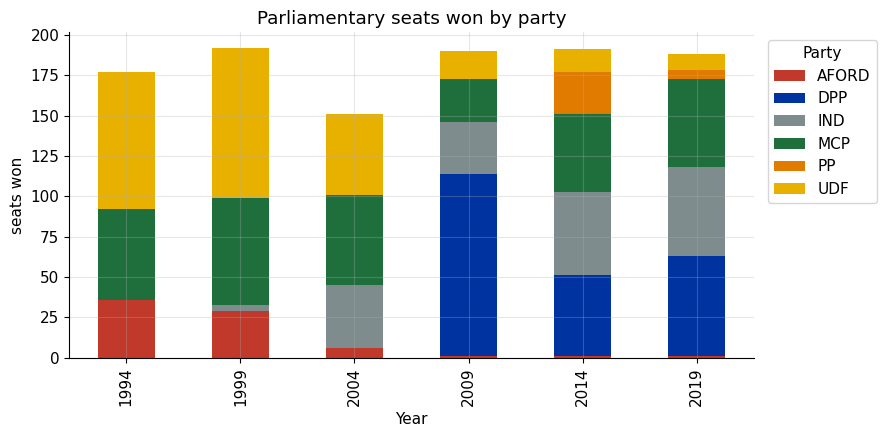

party_canonical,AFORD,DPP,IND,MCP,PP,UDF
year,,,,,,
1994,36.0,0.0,0.0,56.0,0.0,85.0
1999,29.0,0.0,4.0,66.0,0.0,93.0
2004,6.0,0.0,39.0,56.0,0.0,50.0
2009,1.0,113.0,32.0,27.0,0.0,17.0
2014,1.0,50.0,52.0,48.0,26.0,14.0
2019,1.0,62.0,55.0,55.0,5.0,10.0


In [0]:
# --- B3a: presidential districts won, by region x party (per year) ----------
def wins_by_region(pw, year):
    t = (pw[pw.year.eq(year)].groupby(["region","party_canonical"]).size()
           .reset_index(name="districts_won"))
    return t.pivot_table(index="region", columns="party_canonical",
                         values="districts_won", fill_value=0).astype(int)

for yr in [2019, 2020]:
    print(f"\nPresidential districts won - {yr}")
    print(wins_by_region(pw, yr).to_string())

# --- B3b: parliamentary seats won by party by year --------------------------
def constituency_winners(df, etype):
    d  = df[df.election_type.eq(etype)]
    cv = (d.groupby(["year","dk","constituency","candidate","party_canonical"])
            ["votes"].sum().reset_index())
    return cv.sort_values("votes", ascending=False).groupby(
            ["year","dk","constituency"], as_index=False).first()

seats = (constituency_winners(df, "parliamentary")
         .groupby(["year","party_canonical"]).size().reset_index(name="seats"))
top   = seats.groupby("party_canonical")["seats"].sum().sort_values(ascending=False).head(6).index
spiv  = (seats[seats.party_canonical.isin(top)]
         .pivot_table(index="year", columns="party_canonical", values="seats", fill_value=0))

ax = spiv.plot(kind="bar", stacked=True, figsize=(9, 4.5),
               color=[pcol(p) for p in spiv.columns])
ax.set(title="Parliamentary seats won by party", ylabel="seats won", xlabel="Year")
ax.legend(title="Party", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()
spiv


Two things worth flagging for the report. First, the regional win-counts are almost **monolithic** - in 2019 the South returns DPP in all 13 districts, the North goes UTM, the Centre MCP; regional bloc voting is not subtle. Second, the seat chart shows the **independents** (`IND`) surging to ~55 seats by 2014-2019: in Malawi, losing your party primary and running as an independent is a mainstream career move, which is why the seat totals never add cleanly to a two-party story.

## B4 - Region × party vote-share heatmap

The win-*counts* above hide *magnitude* (winning a district 90-10 looks the same as 40-35). A **region × party share heatmap** restores that, and reads at a glance: dark cells are strongholds. Shown for the 2020 presidential race; change `YEAR` to redraw any election.

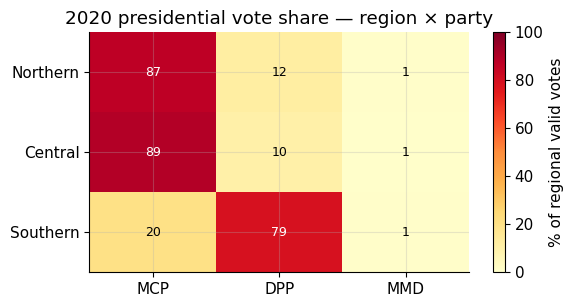

In [0]:
# --- B4: region x party vote-share heatmap ----------------------------------
YEAR = 2020
rr = party_year_share(df, "presidential", level="region")
H  = (rr[rr.year.eq(YEAR)]
      .pivot_table(index="grp", columns="party_canonical", values="share", fill_value=0))
H  = H.loc[["Northern","Central","Southern"]]           # geographic order N->S
H  = H[H.max().sort_values(ascending=False).index]      # strongest party first

fig, ax = plt.subplots(figsize=(1.3*len(H.columns)+2, 3.2))
im = ax.imshow(H.values.astype(float), cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(H.columns))); ax.set_xticklabels(H.columns)
ax.set_yticks(range(len(H.index)));   ax.set_yticklabels(H.index)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                color="white" if v > 55 else "black", fontsize=9)
fig.colorbar(im, label="% of regional valid votes")
ax.set_title(f"{YEAR} presidential vote share - region × party")
plt.tight_layout(); plt.show()


In 2020 MCP takes ~87-89% of the North and Centre while DPP holds ~79% of the South - a near-mirror-image country. That polarisation is exactly why the Tonse coalition worked arithmetically: pooling the North + Centre out-votes a South that, however loyal, is only one of three regions.

## B5 - Dominance map: *how big* was each win

A winner map (B2) is binary; a **margin choropleth** shows intensity - deep colour = blowout, pale = knife-edge. This is the visual behind Metric 2's "safe vs swing" language, but rendered geographically. Presidential 2020 below; the pale districts are where the losing party still put up a real fight.

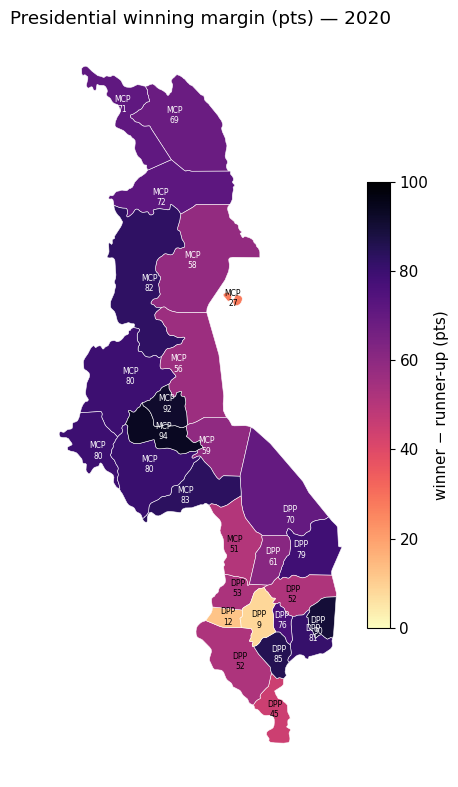

In [0]:
# --- B5: winning-margin choropleth (presidential 2020) ----------------------
import matplotlib.colors as mcolors
YEAR = 2020
wy = district_winners(dvc, "presidential")
wy = wy[wy.year.eq(YEAR)].set_index("key")

fig, ax = plt.subplots(figsize=(6.5, 8))
cmap, nrm = plt.cm.magma_r, mcolors.Normalize(0, 100)
for f in geo["features"]:
    k = f["properties"]["key"]
    m = wy["margin_pct"].get(k, np.nan)
    color = cmap(nrm(m)) if k in wy.index else "#eeeeee"
    for ring in polys_of(f):
        ax.add_patch(MplPolygon(ring[0], closed=True, facecolor=color,
                                edgecolor="white", linewidth=.4))
    if k in wy.index:
        xs = np.vstack([np.array(r[0]) for r in polys_of(f)])
        ax.text(xs[:,0].mean(), xs[:,1].mean(),
                f"{wy['party_canonical'].get(k)}\n{m:.0f}", fontsize=5.5,
                ha="center", va="center",
                color="white" if m > 55 else "black")
ax.autoscale(); ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Presidential winning margin (pts) - {YEAR}")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=nrm); sm.set_array([])
fig.colorbar(sm, ax=ax, fraction=.04, pad=.02).set_label("winner − runner-up (pts)")
plt.tight_layout(); plt.show()


Almost the whole map is dark in 2020 - mean district margin ~65 pts (Metric 2 gave 0.69). The few paler Southern-fringe districts (where MCP made inroads into DPP territory) are the only genuinely contested ground; everywhere else, consolidation turned the contest into a rout.

## B6 - Turnout, handled honestly

Turnout = ballots cast ÷ registered voters. **Two data traps here, both worth stating:**

* **2019** has *no* `registered` values at all.
* **2020**'s `registered` column is present but **corrupted** - it sums to ~18.2 M against ~4.4 M ballots, which would imply a ~24% national turnout when the real figure was ~65%. The column is unusable as-is.

So turnout is computed **only for the years whose registration data is sane** (1994, 1999, 2004, 2009, 2014), and the two bad years are excluded with a visible note. A silent 24% would poison the dashboard.

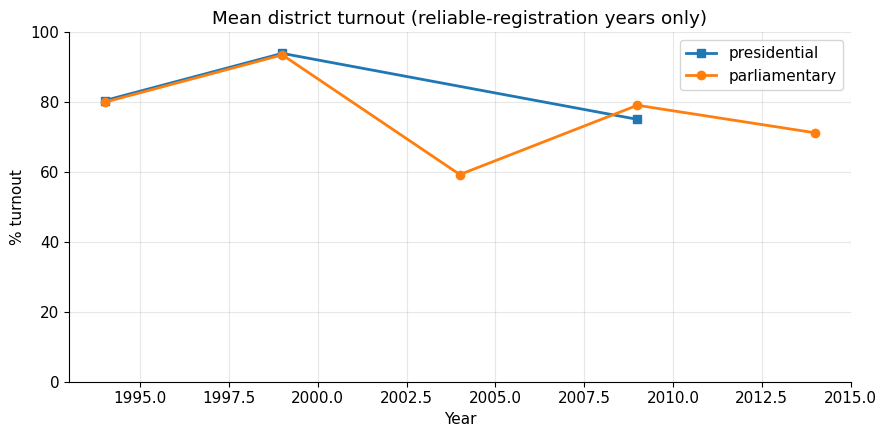

Excluded for bad/missing registration: 2019 (missing), 2020 (corrupted).


,year,election_type,turnout
0,1994,parliamentary,80.0
1,1994,presidential,80.5
2,1999,parliamentary,93.6
3,1999,presidential,94.0
4,2004,parliamentary,59.3
5,2009,parliamentary,79.1
6,2009,presidential,75.1
7,2014,parliamentary,71.2


In [0]:
# --- B6: turnout by year (reliable-registration years only) -----------------
RELIABLE_REG = [1994, 1999, 2004, 2009, 2014]   # 2019 missing, 2020 corrupted

def turnout_by_year(df):
    s = df[df.granularity.eq("station")]; o = df[~df.granularity.eq("station")]
    agg = dict(total=("total_voted","first"), reg=("registered","first"))
    a = s.groupby(["year","election_type","dk","constituency","centre","station"],
                  dropna=False).agg(**agg).reset_index()
    b = o.groupby(["year","election_type","dk","constituency"],
                  dropna=False).agg(**agg).reset_index()
    dd = pd.concat([a.groupby(["year","election_type","dk"])[["total","reg"]].sum(min_count=1),
                    b.groupby(["year","election_type","dk"])[["total","reg"]].sum(min_count=1)]
                   ).reset_index()
    dd = dd[dd.year.isin(RELIABLE_REG)].copy()
    dd["turnout"] = dd["total"] / dd["reg"] * 100
    return dd[(dd.turnout > 0) & (dd.turnout <= 100)]

tt = turnout_by_year(df)
by_year = tt.groupby(["year","election_type"])["turnout"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
for et, mk in [("presidential","s-"), ("parliamentary","o-")]:
    s = by_year[by_year.election_type.eq(et)]
    ax.plot(s.year, s.turnout, mk, label=et, linewidth=2)
ax.set(title="Mean district turnout (reliable-registration years only)",
       ylabel="% turnout", xlabel="Year", ylim=(0, 100))
ax.legend(); plt.tight_layout(); plt.show()
print("Excluded for bad/missing registration: 2019 (missing), 2020 (corrupted).")
by_year.round(1)


The believable series peaks at Malawi's famously high **1999** turnout (~94%) and drifts down thereafter - a common pattern as founding-election enthusiasm fades.

## B7 - More analyses

First: **Gallagher disproportionality** - how far parliamentary *seat* shares diverge from *vote* shares under first-past-the-post (0 = perfectly proportional; higher = more distortion). It's the seat-level companion to Metric 6's wasted votes.

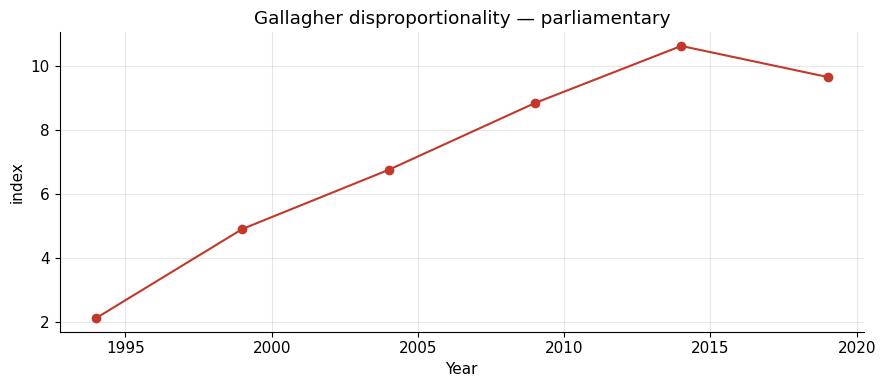

year
1994     2.1
1999     4.9
2004     6.8
2009     8.9
2014    10.6
2019     9.7
dtype: float64

In [0]:
# --- B7a: Gallagher disproportionality index (parliamentary) -----------------
def gallagher(df):
    cv = (df[df.election_type.eq("parliamentary")]
          .groupby(["year","dk","constituency","party_canonical"])["votes"].sum().reset_index())
    vote = cv.groupby(["year","party_canonical"])["votes"].sum().reset_index()
    vote["vote_pct"] = vote["votes"] / vote.groupby("year")["votes"].transform("sum") * 100
    win  = cv.sort_values("votes", ascending=False).groupby(
            ["year","dk","constituency"], as_index=False).first()
    seat = win.groupby(["year","party_canonical"]).size().reset_index(name="seats")
    seat["seat_pct"] = seat["seats"] / seat.groupby("year")["seats"].transform("sum") * 100
    m = vote.merge(seat, on=["year","party_canonical"], how="outer").fillna(0)
    return m.groupby("year").apply(
        lambda x: np.sqrt(0.5 * np.sum((x.vote_pct - x.seat_pct)**2)), include_groups=False)

g = gallagher(df)
ax = g.plot(marker="o", figsize=(9, 4), color="#c0392b")
ax.set(title="Gallagher disproportionality - parliamentary", ylabel="index", xlabel="Year")
plt.tight_layout(); plt.show()
g.round(1)


It climbs from ~2 (1994, near-proportional) to ~10 (2014) - the same fragmentation pressure that inflated wasted votes also made the seat translation steadily less faithful. Next: **bellwether districts** - which districts' presidential winner most often matched the eventual *national* winner. Useful for a dashboard "districts to watch" widget.

In [0]:
# --- B7b: bellwether districts (match the national presidential winner) ------
def bellwether(dvc):
    p = dvc[dvc.election_type.eq("presidential")]
    nat = (p.groupby(["year","party_canonical"])["votes"].sum().reset_index()
             .sort_values("votes", ascending=False).groupby("year").first()["party_canonical"])
    dwin = p.sort_values("votes", ascending=False).groupby(["year","dk"], as_index=False).first()
    dwin["national_winner"] = dwin["year"].map(nat)
    dwin["matched"] = dwin["party_canonical"].eq(dwin["national_winner"])
    out = (dwin.groupby("dk")["matched"].agg(["mean","count"])
             .assign(match_pct=lambda x: (x["mean"]*100).round(0))
             .sort_values("match_pct", ascending=False))
    out.index = out.index.str.title()
    return out[["match_pct","count"]]

bw = bellwether(dvc)
print("Most reliable bellwethers:\n", bw.head(6).to_string())
print("\nLeast (the partisan strongholds that never switch):\n", bw.tail(6).to_string())


Most reliable bellwethers:
           match_pct  count
dk                        
Likoma        100.0      4
Mulanje        83.0      6
Thyolo         83.0      6
Ntcheu         83.0      6
Mwanza         83.0      6
Blantyre       83.0      6

Least (the partisan strongholds that never switch):
           match_pct  count
dk                        
Mzimba         33.0      6
Chitipa        33.0      6
Mchinji        33.0      6
Karonga        33.0      6
Lilongwe       17.0      6
Dedza          17.0      6


## B9 - Persist the descriptive tables

write every computed table to `outputs/` so the report and dashboard read *artefacts*, never re-run the pipeline.

In [0]:
# --- B9: save descriptive outputs -------------------------------------------
import os; os.makedirs("outputs", exist_ok=True)

party_year_share(df, "presidential").to_csv("outputs/b1_pres_national_share.csv", index=False)
party_year_share(df, "parliamentary").to_csv("outputs/b1_parl_national_share.csv", index=False)
district_winners(dvc, "presidential").to_csv("outputs/b2_pres_district_winners.csv", index=False)
seats.to_csv("outputs/b3_parliamentary_seats.csv", index=False)
party_year_share(df, "presidential", level="region").to_csv("outputs/b4_pres_region_share.csv", index=False)
turnout_by_year(df).to_csv("outputs/b6_turnout.csv", index=False)
gallagher(df).rename("gallagher").reset_index().to_csv("outputs/b7_gallagher.csv", index=False)
bellwether(dvc).reset_index().to_csv("outputs/b7_bellwether.csv", index=False)

print("saved:", sorted(f for f in os.listdir("outputs") if f.startswith("b")))


saved: ['b1_parl_national_share.csv', 'b1_pres_national_share.csv', 'b2_pres_district_winners.csv', 'b3_parliamentary_seats.csv', 'b4_pres_region_share.csv', 'b6_turnout.csv', 'b7_bellwether.csv', 'b7_gallagher.csv']


## 4. Save the result tables

persist every computed table so the report/BI layer reads *outputs*, never re-runs the pipeline.

In [0]:
import os
os.makedirs("outputs", exist_ok=True)
parl_enp.to_csv("outputs/m1_parliamentary_enp.csv", index=False)
parl_margins.to_csv("outputs/m2_parliamentary_margins.csv", index=False)
pd.concat([vol_parl.assign(type="parl"), vol_pres.assign(type="pres")]
          ).to_csv("outputs/m3_volatility.csv", index=False)
rc.to_csv("outputs/m4_regional_concentration.csv", index=False)
st_sum.to_csv("outputs/m5_split_ticket.csv", index=False)
parl_winners[["year","district","constituency","wasted_share"]].to_csv("outputs/m6_wasted_votes.csv", index=False)
print("saved:", os.listdir("outputs"))


saved: ['m2b_presidential_swing.csv', 'b1_pres_national_share.csv', 'b1_parl_national_share.csv', 'b2_pres_district_winners.csv', 'b3_parliamentary_seats.csv', 'b4_pres_region_share.csv', 'b6_turnout.csv', 'b7_gallagher.csv', 'm1_parliamentary_enp.csv', 'm2_parliamentary_margins.csv', 'm3_volatility.csv', 'm4_regional_concentration.csv', 'm5_split_ticket.csv', 'm6_wasted_votes.csv', 'b7_bellwether.csv']


## 5. Where this goes next

Two gaps are worth stating explicitly:

1. **2019 turnout is not computable from this file** - `registered` is null for both 2019 races. To finish the *turnout-elasticity* question (2019 → 2020) I need MEC's 2019 registration figures joined on district/constituency.
2. **The dataset ends at 2020.** Adding MEC's **2025** station-level results (Mutharika/DPP 56.8%, MCP alone after UTM left the Tonse Alliance in 2024) would let every metric here tell a *rise-and-fall* arc: fragmentation → consolidation (2020) → re-fragmentation (2025). That contrast is a stronger narrative than 2020 in isolation.

Everything above is a function - swap in a new year's cleaned rows and the whole set of metrics recomputes.